#Proposta

Criar um modelo de NLP para identificar a emoção (positiva ou negativa) em comentários de um catalago em filmes, usando PySpark

##Instalando e iniciando uma sessão Spark

In [1]:
# Install Java
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download and extract Spark
!wget -q http://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Install PySpark
!pip install pyspark==3.5.0

# Set environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

# Initialize SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 6.9 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425346 sha256=5ff6a5dbb715855207524fbf04f0df1486669c8b2508346e8916e34f58ecbf55
  Stored in directory: /root/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.1
    Uninstalling pyspark-4.0.1:
      Successfully uninstalled pyspark-4.0.1
ERROR:

In [2]:
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Explorando os dados

Pegando os dados

In [4]:
dados = spark.read.csv("/content/drive/MyDrive/Curso_Spark/imdb-reviews-pt-br.csv", escape='\"',
                       inferSchema=True, header=True)

Visualizando

In [5]:
dados.limit(5).toPandas()

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


Quantidade de linhas

In [6]:
dados.count()

49459

Quantidade de colunas

In [7]:
len(dados.columns)

4

In [8]:
dados.printSchema() # Visualizando os tipos de dados

root
 |-- id: integer (nullable = true)
 |-- text_en: string (nullable = true)
 |-- text_pt: string (nullable = true)
 |-- sentiment: string (nullable = true)



Visualizando um comentário negativo

In [9]:
dados.filter(dados.id == 190).select("text_pt").show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_pt                                                                                                                          

Visualizando um comentário positivo

In [10]:
dados.filter(dados.id == 12427).select("text_pt").show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_pt                                                                                                                                                                                                                                                                        

In [11]:
dados.filter(dados.sentiment == "pos").show(5)

+-----+--------------------+--------------------+---------+
|   id|             text_en|             text_pt|sentiment|
+-----+--------------------+--------------------+---------+
|12391|I went and saw th...|Eu fui e vi este ...|      pos|
|12392|Actor turned dire...|O diretor do ator...|      pos|
|12393|As a recreational...|Como um jogador d...|      pos|
|12394|I saw this film i...|Eu vi esse filme ...|      pos|
|12395|Bill Paxton has t...|Bill Paxton levou...|      pos|
+-----+--------------------+--------------------+---------+
only showing top 5 rows



Usando groupby para contar a quantidade de comentários classificados em neg ou pos

In [12]:
dados.groupby("sentiment").count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|24694|
|      neg|24765|
+---------+-----+



# Limpeza dos Dados

Remoção de caracteres especiais, espaços e StopWords

Realização da normalização dos dados com lematização e Stemming


Vamos usar as bibliotecas do MLlib do Spark

## Nuvem de palavras / WordCloud

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [14]:
amostra = dados.select("text_pt").sample(fraction = 0.1, seed = 101)

tudo = [texto['text_pt'] for texto in amostra.collect()]

In [15]:
wordcloud = WordCloud(
    collocations=False,
    background_color="white",
    width=800,
    height=400,
    min_word_length=4,
    colormap="viridis"
).generate(str(tudo))

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

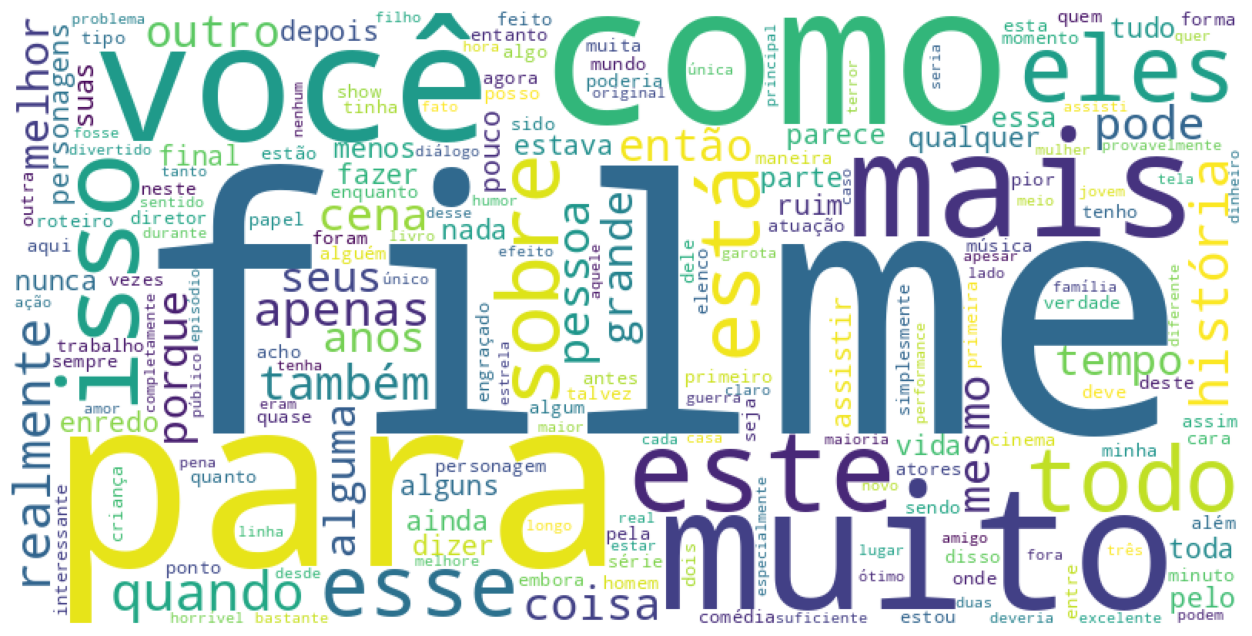

In [16]:
plt.figure(figsize=(20,8))
plt.imshow(wordcloud)
plt.axis("off")

# Removendo Caractere especial

In [17]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

#Regex

In [18]:
import pyspark.sql.functions as f

Removendo todos os caracteres especias usando a função regexp_replace

In [19]:
dados = dados.withColumn("text_regex", f.regexp_replace(f.col("text_en"), "[\$#,\"!%&'()*+-./:;<=>?@^_`´{|}~\\\\]", ""))

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-4170437409.py:1: SyntaxWarning: invalid escape sequence '\$'
  dados = dados.withColumn("text_regex", f.regexp_replace(f.col("text_en"), "[\$#,\"!%&'()*+-./:;<=>?@^_`´{|}~\\\\]", ""))


usando .trim() para retirar os espaços deixados pela remoção de caracteres especiais

In [20]:
dados = dados.withColumn("texto_limpo", f.trim(dados.text_regex))

In [21]:
dados.limit(5).show()

+---+--------------------+--------------------+---------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|
+---+--------------------+--------------------+---------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|Once again Mr Cos...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|This is an exampl...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|First of all I ha...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|Not even the Beat...|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|Brass pictures mo...|
+---+--------------------+--------------------+---------+--------------------+--------------------+



# Tokenização

In [22]:
from pyspark.ml.feature import Tokenizer

In [23]:
tokenizer = Tokenizer(inputCol="texto_limpo", outputCol="tokens")

In [24]:
tokenizado = tokenizer.transform(dados)

In [25]:
tokenizado.select("texto_limpo", "tokens").show()

+--------------------+--------------------+
|         texto_limpo|              tokens|
+--------------------+--------------------+
|Once again Mr Cos...|[once, again, mr,...|
|This is an exampl...|[this, is, an, ex...|
|First of all I ha...|[first, of, all, ...|
|Not even the Beat...|[not, even, the, ...|
|Brass pictures mo...|[brass, pictures,...|
|A funny thing hap...|[a, funny, thing,...|
|This German horro...|[this, german, ho...|
|Being a longtime ...|[being, a, longti...|
|Tokyo Eyes tells ...|[tokyo, eyes, tel...|
|Wealthy horse ran...|[wealthy, horse, ...|
|Cage plays a drun...|[cage, plays, a, ...|
|First of all I wo...|[first, of, all, ...|
|So tell me  what ...|[so, tell, me, , ...|
|A big disappointm...|[a, big, disappoi...|
|This film is abso...|[this, film, is, ...|
|Heres a decidedly...|[heres, a, decide...|
|At the bottom end...|[at, the, bottom,...|
|Earth has been de...|[earth, has, been...|
|Many people are s...|[many, people, ar...|
|New York family i...|[new, york

In [26]:
from pyspark.sql.types import IntegerType

count_tokens: Esta função personalizada do PySpark recebe uma lista de palavras (tokens) e retorna o número de elementos nessa lista, ou seja, a contagem de tokens. O IntegerType() especifica que o retorno da função será um número inteiro.

Aplica a UDF e exibe os resultados: Ele seleciona as colunas texto_limpo (o texto original limpo) e tokens (a lista de palavras tokenizadas) do DataFrame tokenizado.

Em seguida, ele cria uma nova coluna chamada Freq_Tokens aplicando a função count_tokens à coluna tokens, efetivamente contando quantos tokens existem em cada linha. Finalmente, show() exibe as primeiras linhas do DataFrame resultante com a nova coluna de frequência de tokens.

In [29]:
count_tokens = f.udf(lambda words: len(words), IntegerType())
tokenizado.select("texto_limpo", "tokens")\
.withColumn("Freq_Tokens", count_tokens(f.col("tokens"))).show()

+--------------------+--------------------+-----------+
|         texto_limpo|              tokens|Freq_Tokens|
+--------------------+--------------------+-----------+
|Once again Mr Cos...|[once, again, mr,...|        168|
|This is an exampl...|[this, is, an, ex...|        232|
|First of all I ha...|[first, of, all, ...|        215|
|Not even the Beat...|[not, even, the, ...|        308|
|Brass pictures mo...|[brass, pictures,...|        238|
|A funny thing hap...|[a, funny, thing,...|        115|
|This German horro...|[this, german, ho...|        156|
|Being a longtime ...|[being, a, longti...|        136|
|Tokyo Eyes tells ...|[tokyo, eyes, tel...|        129|
|Wealthy horse ran...|[wealthy, horse, ...|        160|
|Cage plays a drun...|[cage, plays, a, ...|        109|
|First of all I wo...|[first, of, all, ...|        333|
|So tell me  what ...|[so, tell, me, , ...|        243|
|A big disappointm...|[a, big, disappoi...|        110|
|This film is abso...|[this, film, is, ...|     

Há um método que já realiza a limpeza de caracteres irregulares e tokeniza automaticamente


RegexTokenizer()

# StopWords

Palavras vázias ou preposições que não trazem significado

###Exemplo

In [30]:
# Exemplo

data = [
    (1, 'Spark é ótimo e NPL com Spark é fácil'),
    (0, 'Spark MLlib não ajuda muito'),
    (1, 'O MLlib do Spark é fácil e ajuda'),
]

colunames = ['label', 'texto_limpo']
df = spark.createDataFrame(data, colunames)
df.show()

+-----+--------------------+
|label|         texto_limpo|
+-----+--------------------+
|    1|Spark é ótimo e N...|
|    0|Spark MLlib não a...|
|    1|O MLlib do Spark ...|
+-----+--------------------+



In [31]:
# Exemplo com nltk
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_A = stopwords.words('portuguese')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [35]:
stop_A

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

In [33]:
# Usando Pyspark

from pyspark.ml.feature import StopWordsRemover

stop_B = StopWordsRemover.loadDefaultStopWords('portuguese')

In [34]:
stop_B

['de',
 'a',
 'o',
 'que',
 'e',
 'do',
 'da',
 'em',
 'um',
 'para',
 'com',
 'não',
 'uma',
 'os',
 'no',
 'se',
 'na',
 'por',
 'mais',
 'as',
 'dos',
 'como',
 'mas',
 'ao',
 'ele',
 'das',
 'à',
 'seu',
 'sua',
 'ou',
 'quando',
 'muito',
 'nos',
 'já',
 'eu',
 'também',
 'só',
 'pelo',
 'pela',
 'até',
 'isso',
 'ela',
 'entre',
 'depois',
 'sem',
 'mesmo',
 'aos',
 'seus',
 'quem',
 'nas',
 'me',
 'esse',
 'eles',
 'você',
 'essa',
 'num',
 'nem',
 'suas',
 'meu',
 'às',
 'minha',
 'numa',
 'pelos',
 'elas',
 'qual',
 'nós',
 'lhe',
 'deles',
 'essas',
 'esses',
 'pelas',
 'este',
 'dele',
 'tu',
 'te',
 'vocês',
 'vos',
 'lhes',
 'meus',
 'minhas',
 'teu',
 'tua',
 'teus',
 'tuas',
 'nosso',
 'nossa',
 'nossos',
 'nossas',
 'dela',
 'delas',
 'esta',
 'estes',
 'estas',
 'aquele',
 'aquela',
 'aqueles',
 'aquelas',
 'isto',
 'aquilo',
 'estou',
 'está',
 'estamos',
 'estão',
 'estive',
 'esteve',
 'estivemos',
 'estiveram',
 'estava',
 'estávamos',
 'estavam',
 'estivera',
 'es

### Tokenizando o exemplo

In [36]:
tokenizer = Tokenizer(inputCol='texto_limpo', outputCol='tokens')
tokenized = tokenizer.transform(df)

### Usando o StopWord do NLKT

In [37]:
remover = StopWordsRemover(inputCol='tokens', outputCol='text_final', stopWords=stop_A)
df = remover.transform(tokenized)

In [39]:
df.show(truncate = False)

+-----+-------------------------------------+-----------------------------------------------+---------------------------------+
|label|texto_limpo                          |tokens                                         |text_final                       |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------+
|1    |Spark é ótimo e NPL com Spark é fácil|[spark, é, ótimo, e, npl, com, spark, é, fácil]|[spark, ótimo, npl, spark, fácil]|
|0    |Spark MLlib não ajuda muito          |[spark, mllib, não, ajuda, muito]              |[spark, mllib, ajuda]            |
|1    |O MLlib do Spark é fácil e ajuda     |[o, mllib, do, spark, é, fácil, e, ajuda]      |[mllib, spark, fácil, ajuda]     |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------+



### Usando o StopWord do Pyspark

In [41]:
remover = StopWordsRemover(inputCol='tokens', outputCol='text_final', stopWords=stop_B)
df = remover.transform(tokenized)
df.show(truncate = False)

+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+
|label|texto_limpo                          |tokens                                         |text_final                             |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+
|1    |Spark é ótimo e NPL com Spark é fácil|[spark, é, ótimo, e, npl, com, spark, é, fácil]|[spark, é, ótimo, npl, spark, é, fácil]|
|0    |Spark MLlib não ajuda muito          |[spark, mllib, não, ajuda, muito]              |[spark, mllib, ajuda]                  |
|1    |O MLlib do Spark é fácil e ajuda     |[o, mllib, do, spark, é, fácil, e, ajuda]      |[mllib, spark, é, fácil, ajuda]        |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+



## Removendo as StopWord da base de dados

In [42]:
remover = StopWordsRemover(inputCol='tokens', outputCol='texto_final')
feature_data = remover.transform(tokenizado)

In [45]:
feature_data.limit(10).show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|              tokens|         texto_final|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|Once again Mr Cos...|[once, again, mr,...|[mr, costner, dra...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|This is an exampl...|[this, is, an, ex...|[example, majorit...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|First of all I ha...|[first, of, all, ...|[first, hate, mor...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the Beat...|Not even the Beat...|[not, even, the, ...|[even, beatles, w...|
|  5|B

In [46]:
#Contagem de tokens antes e depois do stopwords

feature_data.select("tokens", "texto_final")\
.withColumn("Freq_Tokens", count_tokens(f.col("tokens")))\
.withColumn("Freq_Tokens_Limpos", count_tokens(f.col("texto_final"))).show()

+--------------------+--------------------+-----------+------------------+
|              tokens|         texto_final|Freq_Tokens|Freq_Tokens_Limpos|
+--------------------+--------------------+-----------+------------------+
|[once, again, mr,...|[mr, costner, dra...|        168|                73|
|[this, is, an, ex...|[example, majorit...|        232|               131|
|[first, of, all, ...|[first, hate, mor...|        215|               111|
|[not, even, the, ...|[even, beatles, w...|        308|               169|
|[brass, pictures,...|[brass, pictures,...|        238|               140|
|[a, funny, thing,...|[funny, thing, ha...|        115|                52|
|[this, german, ho...|[german, horror, ...|        156|                74|
|[being, a, longti...|[longtime, fan, j...|        136|                73|
|[tokyo, eyes, tel...|[tokyo, eyes, tel...|        129|                75|
|[wealthy, horse, ...|[wealthy, horse, ...|        160|                99|
|[cage, plays, a, ...|[ca

#Vetorização

##Bag of words

Usamos isso para contabilizar todas as palavras presentes no conjunto de dados

In [47]:
from pyspark.ml.feature import CountVectorizer

Este código utiliza o CountVectorizer do PySpark para criar uma representação "Bag of Words" dos dados de texto. Funciona da seguinte forma:

cv = CountVectorizer(inputCol="texto_final", outputCol="CountVec"): Inicializa o CountVectorizer. Ele é configurado para pegar as palavras tokenizadas e limpas da coluna texto_final como entrada e produzir uma nova coluna chamada CountVec, que conterá os vetores de contagem de palavras.


model = cv.fit(feature_data): Esta linha treina o CountVectorizer no seu DataFrame feature_data. Durante esta etapa, o CountVectorizer analisa todos os textos na coluna texto_final e constrói um vocabulário de todas as palavras únicas que ele encontra.


CountVectorizer_features = model.transform(feature_data): Finalmente, esta linha aplica o modelo treinado (model) ao seu feature_data. Ele usa o vocabulário aprendido para converter cada lista de palavras na coluna texto_final em um vetor numérico (CountVec).


Cada elemento neste vetor representa a contagem de uma palavra específica do vocabulário nesse texto, formando a representação "Bag of Words" para análise posterior.

In [48]:
cv = CountVectorizer(inputCol="texto_final", outputCol="CountVec")
model = cv.fit(feature_data)
CountVectorizer_features = model.transform(feature_data)

In [49]:
CountVectorizer_features.select("texto_final", "CountVec").limit(5).show()

+--------------------+--------------------+
|         texto_final|            CountVec|
+--------------------+--------------------+
|[mr, costner, dra...|(216710,[0,7,8,11...|
|[example, majorit...|(216710,[1,2,3,8,...|
|[first, hate, mor...|(216710,[0,2,4,11...|
|[even, beatles, w...|(216710,[0,1,2,4,...|
|[brass, pictures,...|(216710,[1,3,5,8,...|
+--------------------+--------------------+



In [51]:
model.vocabulary

['movie',
 'film',
 'one',
 '',
 'like',
 'good',
 'even',
 'time',
 'really',
 'see',
 'story',
 'much',
 'well',
 'get',
 'great',
 'bad',
 'people',
 'also',
 'first',
 'dont',
 'movies',
 'made',
 'make',
 'films',
 'way',
 'characters',
 'think',
 'watch',
 'seen',
 'many',
 'two',
 'never',
 'character',
 'acting',
 'love',
 'plot',
 'little',
 'best',
 'know',
 'show',
 'ever',
 'life',
 'better',
 'say',
 'still',
 'end',
 'scene',
 'scenes',
 'man',
 'something',
 'go',
 'im',
 'watching',
 'back',
 'real',
 'thing',
 'actors',
 'didnt',
 'doesnt',
 'years',
 'funny',
 'actually',
 'though',
 'makes',
 'find',
 'nothing',
 'another',
 'look',
 'lot',
 'going',
 'work',
 'new',
 'every',
 'old',
 'part',
 'cant',
 'us',
 'want',
 'pretty',
 'director',
 'quite',
 'thats',
 'cast',
 'things',
 'got',
 'seems',
 'young',
 'around',
 'take',
 'fact',
 'thought',
 'enough',
 'give',
 'world',
 'big',
 'horror',
 'ive',
 'may',
 'saw',
 'however',
 'isnt',
 'always',
 'long',
 'with

##Hashing TF

Alternativa para o CountVector

Podemos limitar a quantidade de palavras

In [52]:
from pyspark.ml.feature import HashingTF

In [53]:
hashingTF = HashingTF(inputCol="texto_final", outputCol="HashingTF")
hashingTF.setNumFeatures(50) # limitando o vocabulario em 50
hashingTF_feature_data = hashingTF.transform(feature_data)

In [54]:
hashingTF_feature_data.select("texto_final", "HashingTF").limit(5).show()

+--------------------+--------------------+
|         texto_final|           HashingTF|
+--------------------+--------------------+
|[mr, costner, dra...|(50,[0,5,6,7,8,10...|
|[example, majorit...|(50,[0,1,2,3,4,5,...|
|[first, hate, mor...|(50,[0,1,2,3,5,6,...|
|[even, beatles, w...|(50,[0,1,2,3,4,5,...|
|[brass, pictures,...|(50,[0,1,2,3,4,5,...|
+--------------------+--------------------+



##TF-IDF

Contabiliza e pondera as palavras

TF-IDF significa Term Frequency - Inverse Document Frequency ou Frequência do Termo - Inverso da Frequência no Documento que não só contabiliza as palavras, mas também pondera

In [55]:
from pyspark.ml.feature import IDF

In [56]:
idf = IDF(inputCol="HashingTF", outputCol="features")
idf_model = idf.fit(hashingTF_feature_data)
IDFfeature = idf_model.transform(hashingTF_feature_data)

In [58]:
IDFfeature.select('texto_final', 'features').limit(5).show(truncate = False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#Pipeline de transformação

In [59]:
IDFfeature.groupby('sentiment').count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|24694|
|      neg|24765|
+---------+-----+



## Criando os labels para Neg e Pos

In [60]:
from pyspark.ml.feature import StringIndexer

In [61]:
stringIndexer = StringIndexer(inputCol="sentiment", outputCol="label")
dados = stringIndexer.fit(dados).transform(dados)

In [62]:
dados.groupby(['sentiment', 'label']).count().show()

+---------+-----+-----+
|sentiment|label|count|
+---------+-----+-----+
|      pos|  1.0|24694|
|      neg|  0.0|24765|
+---------+-----+-----+



In [63]:
from pyspark.ml import Pipeline

In [64]:
#definindo passos
tokenizer = Tokenizer(inputCol="texto_limpo", outputCol="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="texto_final")
hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol="HTF", numFeatures=1000)
idf = IDF(inputCol="HTF", outputCol="features")

#criando o pipeline com a ordem dos passos
pipeline = Pipeline(stages=[tokenizer, stopwords, hashingTF, idf])

In [65]:
dados_transformados = pipeline.fit(dados).transform(dados)

In [66]:
dados_transformados.limit(5).show()

+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|label|              tokens|         texto_final|                 HTF|            features|
+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|Once again Mr Cos...|  0.0|[once, again, mr,...|[mr, costner, dra...|(1000,[10,21,34,4...|(1000,[10,21,34,4...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|This is an exampl...|  0.0|[this, is, an, ex...|[example, majorit...|(1000,[0,3,11,12,...|(1000,[0,3,11,12,...|
|  3|First of all I ha...|Primeiro de tudo ...|   

#Possíveis modelos

Devemos focar em utilizar algoritimos de classificação, pois o objetivo é classificar os comentários em positivo ou negativo

Podemos usar:

Regressão Logística

Árvore de Decisão

XGBoost

#Árvore Decisão

In [67]:
featureDF = dados_transformados.select("features", "label")

In [68]:
featureDF.limit(5).show(truncate = False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [69]:
featureDF.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: double (nullable = false)



In [70]:
from pyspark.ml.classification import DecisionTreeClassifier

In [76]:
#Atualizando o Pipeline com o ajuste da árvore de decisão

#definindo passos
tokenizer = Tokenizer(inputCol="texto_limpo", outputCol="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="texto_final")
hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol="HTF", numFeatures=1000)
idf = IDF(inputCol="HTF", outputCol="features")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth= 10)

#criando o pipeline com a ordem dos passos
pipeline = Pipeline(stages=[tokenizer, stopwords, hashingTF, idf, dt])

#Amostra e Treino

In [78]:
#Separando os dados
train, test = dados.randomSplit([0.7, 0.3], seed = 101)

In [79]:
#ajustando o modelo com o pipeline

dt_model = pipeline.fit(train)

In [80]:
predictions = dt_model.transform(test)

In [81]:
predictions.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+----------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|label|              tokens|         texto_final|                 HTF|            features|  rawPrediction|         probability|prediction|
+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+----------+
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|Brass pictures mo...|  0.0|[brass, pictures,...|[brass, pictures,...|(1000,[3,6,7,11,3...|(1000,[3,6,7,11,3...| [366.0,1112.0]|[0.24763193504736...|       1.0|
|  6|A funny thing hap...|Uma coisa engraça...| 

#Teste e métricas

In [82]:
predictions.select("prediction", "label").show()

+----------+-----+
|prediction|label|
+----------+-----+
|       1.0|  0.0|
|       1.0|  0.0|
|       1.0|  0.0|
|       1.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       1.0|  0.0|
|       0.0|  0.0|
|       1.0|  0.0|
|       1.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       1.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
|       0.0|  0.0|
+----------+-----+
only showing top 20 rows



In [83]:
#Acuracia
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [84]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

In [85]:
acuracia = evaluator.evaluate(predictions)
print(f"Acurácia: {acuracia}")

Acurácia: 0.6700404858299596


#Nova frase

In [89]:
nova_base = spark.createDataFrame([
    (0, "This is without any doubt the worst movie I have ever seen, I hated the acting of the actors"),
    (1, "I loved the movie, excellent acting"),
    (2, "I didn't like at all, the movie was so bad")

], ["id", "texto_limpo"])

In [90]:
nova_classe = dt_model.transform(nova_base)

In [91]:
nova_classe.show()

+---+--------------------+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+----------+
| id|         texto_limpo|              tokens|         texto_final|                 HTF|            features| rawPrediction|         probability|prediction|
+---+--------------------+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+----------+
|  0|This is without a...|[this, is, withou...|[without, doubt, ...|(1000,[35,43,134,...|(1000,[35,43,134,...|   [18.0,10.0]|[0.64285714285714...|       0.0|
|  1|I loved the movie...|[i, loved, the, m...|[loved, movie,, e...|(1000,[185,734,78...|(1000,[185,734,78...| [156.0,774.0]|[0.16774193548387...|       1.0|
|  2|I didn't like at ...|[i, didn't, like,...|[like, all,, movi...|(1000,[161,330,43...|(1000,[161,330,43...|[1341.0,317.0]|[0.80880579010856...|       0.0|
+---+--------------------+--------------------+-----

### Nova frase classificada com sucesso

In [92]:
spark.stop()